### generate multilabel confusion matrix with data input from excel assessment of results
need to work on staying in python and not excel

In [1]:
pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.5 MB/s  0:00:00m0:00:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [68]:
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
import seaborn as sns
import pandas as pd



In [69]:
# ground truth
gt_train_rpts = pd.read_excel(io='/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/bondsAllocsJune7.xlsx', sheet_name='ground_truth_train', dtype={'pdfname': str, "gt_source": str, "ES_0_percent": bool, "ES_100_percent": bool, "ES_partial": bool, "number_of_cats": int})
gt_train_df = pd.DataFrame(gt_train_rpts)
gt_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   pdfname         34 non-null     str  
 1   gt_source       34 non-null     str  
 2   ES_0_percent    34 non-null     bool 
 3   ES_100_percent  34 non-null     bool 
 4   ES_partial      34 non-null     bool 
 5   number_of_cats  34 non-null     int64
dtypes: bool(3), int64(1), str(2)
memory usage: 2.5 KB


In [70]:
# create y_true based on ES percent cols
ES_percent_true = []
for r in gt_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_true.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_true.append('ES 100%')
    elif r.ES_partial:
        ES_percent_true.append('ES partial')
gt_train_df['ES_percent_true'] = ES_percent_true

In [80]:
# pipeline predictions - V4 sim TH = 0.65
pred_train_rpts = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V4.csv')
pred_train_df = pd.DataFrame(pred_train_rpts)
pred_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34 non-null     int64  
 1   pdfname               34 non-null     str    
 2   nlp_path              34 non-null     str    
 3   language              34 non-null     str    
 4   similarity_threshold  34 non-null     float64
 5   cleanup_threshold     34 non-null     float64
 6   ES_0_percent          34 non-null     bool   
 7   ES_100_percent        34 non-null     bool   
 8   ES_partial            34 non-null     bool   
 9   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 3.7 KB


In [81]:
# pipeline predictions - V5 sim TH = 0.80
pred_train_rpts_v5 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V5.csv')
pred_train_df_v5 = pd.DataFrame(pred_train_rpts_v5)
pred_train_df_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34 non-null     int64  
 1   pdfname               34 non-null     str    
 2   nlp_path              34 non-null     str    
 3   language              34 non-null     str    
 4   similarity_threshold  34 non-null     float64
 5   cleanup_threshold     34 non-null     float64
 6   ES_0_percent          34 non-null     bool   
 7   ES_100_percent        34 non-null     bool   
 8   ES_partial            34 non-null     bool   
 9   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 3.7 KB


In [82]:
# create y_pred based on ES percent cols - V4 sim TH = 0.65
ES_percent_pred = []
for r in pred_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df['ES_percent_pred'] = ES_percent_pred


In [83]:
# create y_pred based on ES percent cols - V5 sim TH = 0.80
ES_percent_pred = []
for r in pred_train_df_v5.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v5['ES_percent_pred'] = ES_percent_pred

In [84]:
# create a dataset containing results for confusion matrix - V4 sim TH = 0.65

conf_mtrx_df = pd.DataFrame()

conf_mtrx_df['pdfname'] = pred_train_df['pdfname']
conf_mtrx_df['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df['nlp_path'] = pred_train_df['nlp_path']
conf_mtrx_df['language'] = pred_train_df['language']
conf_mtrx_df['similarity_th'] = pred_train_df['similarity_threshold']
conf_mtrx_df['cleanup_th'] = pred_train_df['cleanup_threshold']
conf_mtrx_df['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df['ES_percent_pred'] = pred_train_df['ES_percent_pred']
conf_mtrx_df['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df['num_cats_pred'] = pred_train_df['number_of_cats']
conf_mtrx_df['num_cats_diff'] = conf_mtrx_df['num_cats_true'] - conf_mtrx_df['num_cats_pred']


In [85]:
# create a dataset containing results for confusion matrix - V5 sim TH = 0.80

conf_mtrx_df_v5 = pd.DataFrame()

conf_mtrx_df_v5['pdfname'] = pred_train_df_v5['pdfname']
conf_mtrx_df_v5['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v5['nlp_path'] = pred_train_df_v5['nlp_path']
conf_mtrx_df_v5['language'] = pred_train_df_v5['language']
conf_mtrx_df_v5['similarity_th'] = pred_train_df_v5['similarity_threshold']
conf_mtrx_df_v5['cleanup_th'] = pred_train_df_v5['cleanup_threshold']
conf_mtrx_df_v5['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v5['ES_percent_pred'] = pred_train_df_v5['ES_percent_pred']
conf_mtrx_df_v5['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v5['num_cats_pred'] = pred_train_df_v5['number_of_cats']
conf_mtrx_df_v5['num_cats_diff'] = conf_mtrx_df_v5['num_cats_true'] - conf_mtrx_df_v5['num_cats_pred']

In [86]:
# create ES Partial TP col based on ES percent cols - V4 sim TH = 0.65
ES_partial_True_Positives = []
for r in conf_mtrx_df.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df['ES_partial_True_Positives'].value_counts()
conf_mtrx_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [87]:
# create ES Partial TP col based on ES percent cols - V5 sim TH = 0.80
ES_partial_True_Positives = []
for r in conf_mtrx_df_v5.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v5['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v5['ES_partial_True_Positives'].value_counts()
conf_mtrx_df_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [88]:
# bring in data from eval - V4 sim TH = 0.65

y_true = conf_mtrx_df['ES_percent_true']
y_pred = conf_mtrx_df['ES_percent_pred']
labels = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true, y_pred, labels=labels)

array([[[28,  2],
        [ 4,  0]],

       [[21,  2],
        [ 9,  2]],

       [[ 2, 13],
        [ 4, 15]]])

In [89]:
# bring in data from eval - V5 sim TH = 0.80

y_true_v5 = conf_mtrx_df_v5['ES_percent_true']
y_pred_v5 = conf_mtrx_df_v5['ES_percent_pred']
labels_v5 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v5, y_pred_v5, labels=labels_v5)

array([[[26,  4],
        [ 3,  1]],

       [[20,  3],
        [10,  1]],

       [[ 6,  9],
        [ 3, 16]]])

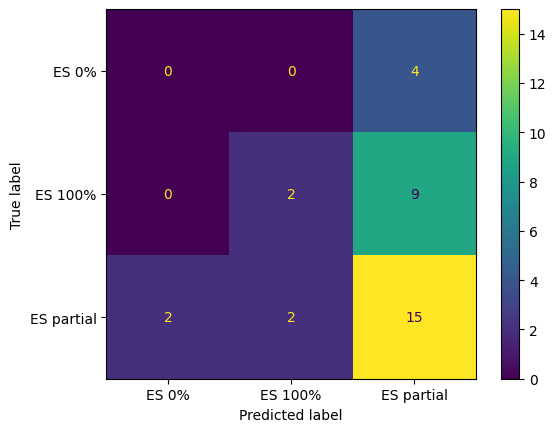

In [90]:
# display confusion matrix - V4 sim TH = 0.65

cm = multilabel_confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

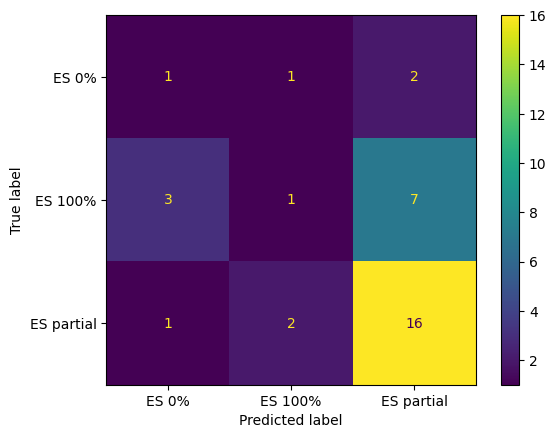

In [91]:
# display confusion matrix - V5 sim TH = 0.80

cm = multilabel_confusion_matrix(y_true_v5, y_pred_v5)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v5, y_pred_v5)
plt.show()


In [92]:
# accuracy metrix - V4 sim TH = 0.65

accuracy_score_frac = accuracy_score(y_true, y_pred)
accuracy_score_num = accuracy_score(y_true, y_pred, normalize=False)

print(accuracy_score_frac, accuracy_score_num)

f1 = f1_score(y_true, y_pred, average='macro')
print(f1)

0.5 17.0
0.3016548463356974


In [93]:
# accuracy metrix - V5 sim TH = 0.80

accuracy_score_frac_v5 = accuracy_score(y_true_v5, y_pred_v5)
accuracy_score_num_v5 = accuracy_score(y_true_v5, y_pred_v5, normalize=False)

print(accuracy_score_frac_v5, accuracy_score_num_v5)

f1_v5 = f1_score(y_true_v5, y_pred_v5, average='macro')
print(f1_v5)

0.5294117647058824 18.0
0.3609427609427609


In [94]:
# create a dataset containing results for boxplots - V4 sim TH = 0.65

boxplot_df = conf_mtrx_df.query("ES_partial_True_Positives == True")
boxplot_df.info()


<class 'pandas.DataFrame'>
Index: 15 entries, 0 to 32
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    15 non-null     str    
 1   gt_source                  15 non-null     str    
 2   nlp_path                   15 non-null     str    
 3   language                   15 non-null     str    
 4   similarity_th              15 non-null     float64
 5   cleanup_th                 15 non-null     float64
 6   ES_percent_true            15 non-null     str    
 7   ES_percent_pred            15 non-null     str    
 8   num_cats_true              15 non-null     int64  
 9   num_cats_pred              15 non-null     int64  
 10  num_cats_diff              15 non-null     int64  
 11  ES_partial_True_Positives  15 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.6 KB


In [95]:
# create a dataset containing results for boxplots - V5 sim TH = 0.80

boxplot_df_v5 = conf_mtrx_df_v5.query("ES_partial_True_Positives == True")
boxplot_df_v5.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 2 to 32
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    16 non-null     str    
 1   gt_source                  16 non-null     str    
 2   nlp_path                   16 non-null     str    
 3   language                   16 non-null     str    
 4   similarity_th              16 non-null     float64
 5   cleanup_th                 16 non-null     float64
 6   ES_percent_true            16 non-null     str    
 7   ES_percent_pred            16 non-null     str    
 8   num_cats_true              16 non-null     int64  
 9   num_cats_pred              16 non-null     int64  
 10  num_cats_diff              16 non-null     int64  
 11  ES_partial_True_Positives  16 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.7 KB


<Axes: xlabel='num_cats_diff', ylabel='gt_source'>

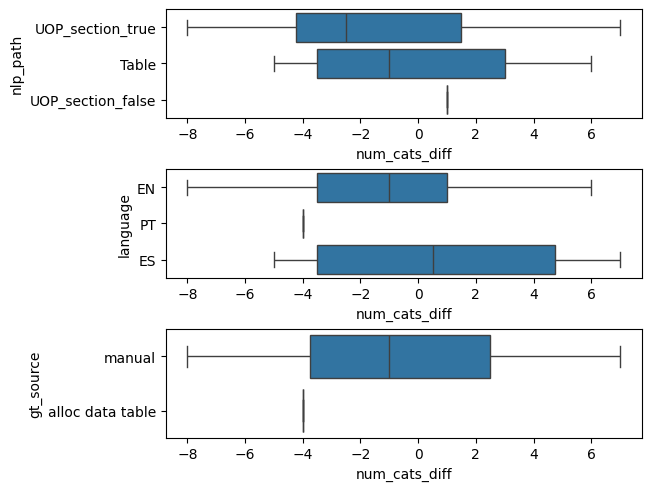

In [96]:
# boxplots of diff in number of cats - V4 sim TH = 0.65

fig, axes = plt.subplots(3,1, layout = 'constrained')

sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['nlp_path'], ax=axes[0])
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['language'], ax=axes[1])
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['gt_source'], ax=axes[2])

In [100]:
# stats - whole dataset and ES partial TPs - V4 sim TH = 0.65

print(conf_mtrx_df['num_cats_true'].describe())
print(conf_mtrx_df['num_cats_diff'].describe())
print(boxplot_df['num_cats_true'].describe())
print(boxplot_df['num_cats_diff'].describe())

count    34.000000
mean      3.294118
std       4.310167
min       0.000000
25%       0.000000
50%       2.000000
75%       5.750000
max      17.000000
Name: num_cats_true, dtype: float64
count    34.000000
mean     -1.588235
std       5.039947
min     -10.000000
25%      -4.750000
50%      -2.000000
75%       0.750000
max      10.000000
Name: num_cats_diff, dtype: float64
count    15.000000
mean      5.200000
std       3.949684
min       2.000000
25%       2.000000
50%       4.000000
75%       6.500000
max      17.000000
Name: num_cats_true, dtype: float64
count    15.000000
mean     -0.733333
std       4.366539
min      -8.000000
25%      -4.000000
50%      -2.000000
75%       2.000000
max       7.000000
Name: num_cats_diff, dtype: float64


<Axes: xlabel='num_cats_diff', ylabel='gt_source'>

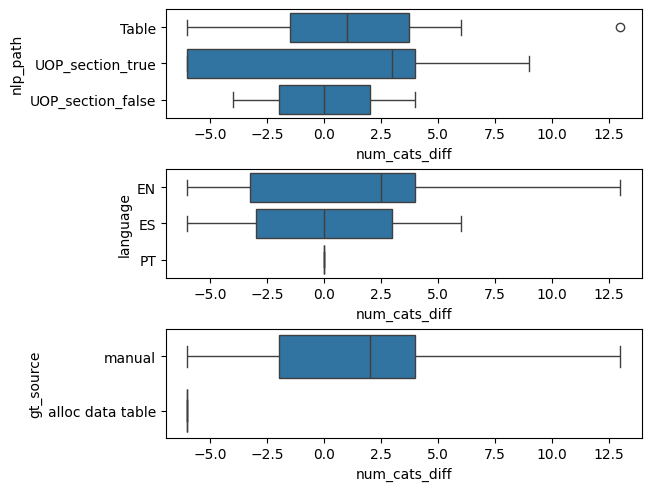

In [101]:
# boxplots of diff in number of cats - V5 sim TH = 0.80

fig, axes = plt.subplots(3,1, layout = 'constrained')

sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['nlp_path'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['language'], ax=axes[1])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['gt_source'], ax=axes[2])

In [102]:
# stats - whole dataset and ES partial TPs - V5 sim TH = 0.80

print(conf_mtrx_df_v5['num_cats_true'].describe())
print(conf_mtrx_df_v5['num_cats_diff'].describe())
print(boxplot_df_v5['num_cats_true'].describe())
print(boxplot_df_v5['num_cats_diff'].describe())

count    34.000000
mean      3.294118
std       4.310167
min       0.000000
25%       0.000000
50%       2.000000
75%       5.750000
max      17.000000
Name: num_cats_true, dtype: float64
count    34.000000
mean     -0.676471
std       5.156465
min     -10.000000
25%      -4.000000
50%      -2.000000
75%       2.750000
max      13.000000
Name: num_cats_diff, dtype: float64
count    16.000000
mean      5.812500
std       4.323868
min       2.000000
25%       2.000000
50%       4.500000
75%       8.000000
max      17.000000
Name: num_cats_true, dtype: float64
count    16.000
mean      1.125
std       5.500
min      -6.000
25%      -3.250
50%       1.000
75%       4.000
max      13.000
Name: num_cats_diff, dtype: float64
